# MFCC

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

In [2]:
dataset_path= "/home/jovana/Desktop/projects/Wake  word detection/dataset_wake_word_detection"
wake_word= "stop"

wake_word_folder= os.path.join(
    dataset_path,
    wake_word
)

files= os.listdir(wake_word_folder)

#example file
audio_file= os.path.join(
    wake_word_folder,
    files[66]
)

print(audio_file)

/home/jovana/Desktop/projects/Wake  word detection/dataset_wake_word_detection/stop/f19c1390_nohash_4.wav


In [3]:
signal, sr= librosa.load(
    audio_file,
    sr=16000
)

print("Sample rate:", sr)

print("Signal shape:", signal.shape)

Sample rate: 16000
Signal shape: (16000,)


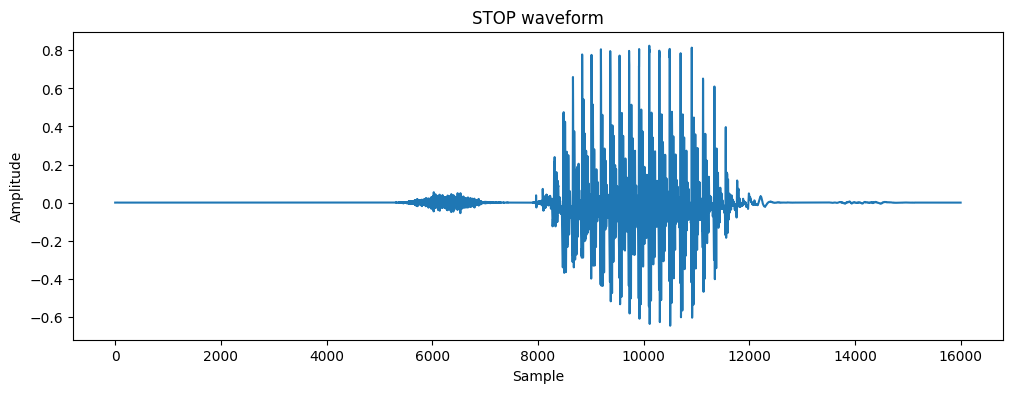

In [4]:
plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("STOP waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [5]:
Audio(signal, rate=sr)

In [6]:
mfcc= librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

print(mfcc.shape)

(13, 32)


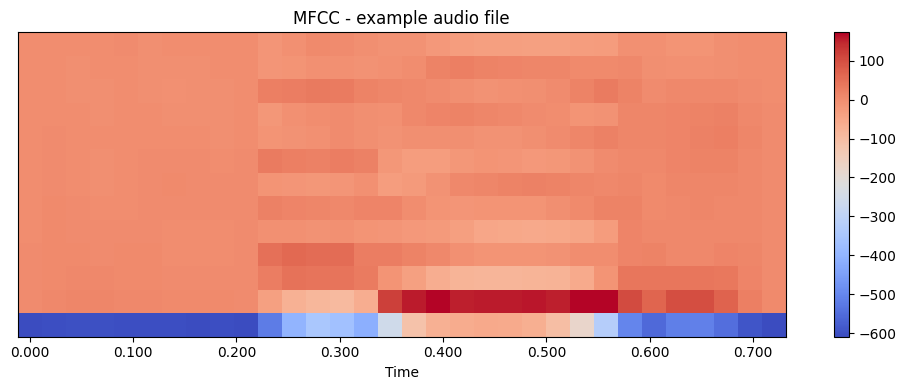

In [7]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC - example audio file")
plt.tight_layout()
plt.show()

In [8]:
def extract_mfcc(file_path, n_mfcc=13, max_len=32):
    signal, sr= librosa.load(
        file_path,
        sr=16000
    )

    mfcc= librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc
    )

    
    if mfcc.shape[1] < max_len:
        pad_width= max_len - mfcc.shape[1]

        mfcc= np.pad(
            mfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )
    else:
        mfcc= mfcc[:, :max_len]

    return mfcc

In [9]:
X= []
y= []

In [10]:
for file_name in os.listdir(wake_word_folder):
    if file_name.endswith(".wav"):
        file_path= os.path.join(
            wake_word_folder,
            file_name
        )

        mfcc= extract_mfcc(file_path)

        X.append(mfcc)
        y.append(1)

In [11]:
for folder_name in os.listdir(dataset_path):
    folder_path= os.path.join(
        dataset_path,
        folder_name
    )

    if not os.path.isdir(folder_path):
        continue

    if folder_name == wake_word:
        continue

    if folder_name.startswith("_"):
        continue

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".wav"):
            file_path= os.path.join(
                folder_path,
                file_name
            )

            mfcc = extract_mfcc(file_path)

            X.append(mfcc)
            y.append(0)

In [12]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (64721, 13, 32)
y shape: (64721,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (48540, 13, 32)
X_test: (16181, 13, 32)
y_train: (48540,)
y_test: (16181,)


# LFCC